# Projet 12 - ZenAssist : Étape 2 - Évaluation de l'approche LLM (Google Gemini)

Ce notebook met en œuvre et évalue l'approche basée sur un **Large Language Model (LLM)** avec **Google Gemini (`gemini-3.5-flash-lite`)** pour classifier automatiquement les réclamations clients par catégorie produit.

### Objectifs :
1. **Charger la clé API en toute sécurité** depuis `.env.local` (ou `.env`).
2. **Configurer l'API Google Gemini** (`google.genai`).
3. **Gérer automatiquement les quotas d'API** (Gestion des retries si nécessaire).
4. **Concevoir et itérer sur les Prompts** (Prompt Engineering : Zero-shot avec règles & définitions strictes + consigne d'anonymisation).
5. **Valider l'approche** sur un échantillon initial de 20 réclamations.
6. **Évaluer la solution à grande échelle** sur l'échantillon stratifié de **1 000 réclamations** (`dataset/llm_test_sample.csv`).
7. **Calculer les métriques de performance** (Accuracy, Precision, Recall, F1-score, Matrice de confusion) et la **latence moyenne**.
8. **Sauvegarder les résultats et visualisations**.

In [11]:
import os
import sys
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from dotenv import load_dotenv

# Chargement automatique des clés secrètes depuis .env.local
load_dotenv('.env.local')
load_dotenv('.env')


# Import SDK Google GenAI
try:
    from google import genai
    from google.genai import types
    print('Google GenAI SDK (google-genai) chargé avec succès !')
except ImportError:
    import google.generativeai as genai
    print('Google GenerativeAI (Legacy) chargé.')

plt.style.use('ggplot')
sns.set_palette('viridis')
%matplotlib inline

Google GenAI SDK (google-genai) chargé avec succès !


## 1. Initialisation de l'API Google Gemini

In [3]:
# Récupération de la clé API
api_key = os.environ.get('GEMINI_API_KEY') or os.environ.get('GOOGLE_API_KEY')

if not api_key:
    raise ValueError('Clé API introuvable ! Assurez-vous d\'avoir créé un fichier .env.local avec GEMINI_API_KEY=votre_cle')

MODEL_NAME = os.environ.get('GEMINI_MODEL', 'gemini-3.5-flash-lite')
client = genai.Client(api_key=api_key)
print(f'Client Gemini initialisé avec le modèle : {MODEL_NAME}')

Client Gemini initialisé avec le modèle : gemini-3.5-flash-lite


## 2. Chargement des Données & Taxonomie des Catégories

In [4]:
sample_path = 'dataset/llm_test_sample.csv'
df_sample = pd.read_csv(sample_path)

print(f'Échantillon de test chargé : {len(df_sample):,} exemples')
print('Catégories uniques à prédire :')
CATEGORIES = sorted(df_sample['Tag_Clean'].unique().tolist())
for i, cat in enumerate(CATEGORIES, 1):
    print(f' {i}. {cat}')

df_sample.head()

Échantillon de test chargé : 1,000 exemples
Catégories uniques à prédire :
 1. Bank account / Savings
 2. Credit card / Prepaid card
 3. Credit reporting
 4. Debt collection
 5. Money transfer / Crypto
 6. Mortgage
 7. Other financial service
 8. Payday & Personal loan
 9. Student loan
 10. Vehicle loan / Lease


,Consumer Claim,Tag_Clean
0,"TransUnion stated it "" verified '' and validat...",Credit reporting
1,I open account with chase bank in Nevada I had...,Bank account / Savings
2,Ace Cash Express has sent my non-payment to an...,Payday & Personal loan
3,I contacted XXXX XXXX today XX/XX/2019 in effo...,Student loan
4,"I was charged "" excess tax fees '' multiple ti...",Bank account / Savings


## 3. Conception et Ingénierie des Prompts (Prompt Engineering) avec Retry Automatique

In [5]:
PROMPT_SYSTEM_V2 = f"""Tu es un expert en classification automatique de réclamations de services financiers chez ZenAssist.
Ta mission est d'analyser le texte de la réclamation d'un client et de la classer dans EXACTEMENT UNE des catégories suivantes :

Catégories autorisées :
1. Credit reporting (Problèmes de rapports de crédit, corrections d'erreurs, agences de crédit)
2. Debt collection (Recouvrement de créances, harcèlement, sommes déjà payées)
3. Mortgage (Prêts immobiliers, saisies, frais d'hypothèque)
4. Credit card / Prepaid card (Cartes de crédit, cartes prépayées, frais non autorisés)
5. Bank account / Savings (Comptes courants, épargne, agios, virements bancaires d'agence)
6. Student loan (Prêts étudiants, remboursements, frais de scolarité)
7. Payday & Personal loan (Prêts personnels, prêts à court terme / à la journée)
8. Money transfer / Crypto (Transferts d'argent internationaux, services de monnaie virtuelle, crypto)
9. Vehicle loan / Lease (Prêts automobiles, leasing de véhicules)
10. Other financial service (Autres services financiers divers)

Règles impératives :
- Réponds UNIQUEMENT par le nom exact de la catégorie figurant dans la liste ci-dessus.
- Ne rajoute AUCUN texte d'introduction, AUCUNE explication, ni AUCUNE ponctuation supplémentaire.
- Note : Les caractères 'XXXX' ou 'XX' sont des masques d'anonymisation de données personnelles. Ignore-les et concentre-toi sur le contexte sémantique de la réclamation.
"""

def classify_claim_llm(claim_text, system_instruction=PROMPT_SYSTEM_V2, max_retries=5):
    prompt = f"Réclamation client :\n\"\"\"\n{claim_text}\n\"\"\"\n\nCatégorie :"
    start_time = time.perf_counter()
    
    for attempt in range(1, max_retries + 1):
        try:
            response = client.models.generate_content(
                model=MODEL_NAME,
                contents=prompt,
                config=types.GenerateContentConfig(
                    system_instruction=system_instruction,
                    temperature=0.0,
                    max_output_tokens=30,
                )
            )
            text_out = response.text.strip() if response and response.text else "Erreur"
            elapsed = time.perf_counter() - start_time
            return text_out, elapsed
            
        except Exception as e:
            err_str = str(e)
            if '429' in err_str or 'RESOURCE_EXHAUSTED' in err_str:
                wait_sec = 10 * attempt
                print(f"\n   ⚠️ [Quota 429] Limite de requêtes atteinte. Pause de {wait_sec}s avant retry {attempt+1}/{max_retries}...")
                time.sleep(wait_sec)
            else:
                print(f"\n   ❌ Erreur API : {e}")
                elapsed = time.perf_counter() - start_time
                return "Erreur", elapsed
                
    elapsed = time.perf_counter() - start_time
    return "Erreur (Quota dépassé)", elapsed

## 4. Test initial sur un échantillon de 20 réclamations (Validation)

In [6]:
print('--- Test initial sur 20 réclamations ---')
subset_20 = df_sample.head(20).copy()

preds_20 = []
times_20 = []

for idx, row in subset_20.iterrows():
    pred, t = classify_claim_llm(row['Consumer Claim'])
    preds_20.append(pred)
    times_20.append(t)
    print(f"[Ticket {idx+1:02d}] Réel: {row['Tag_Clean']:<25} | Prédit: {pred:<25} ({t:.2f}s)")
    time.sleep(0.1)

def clean_sub(val):
    val_str = str(val).strip()
    for cat in CATEGORIES:
        if cat.lower() in val_str.lower():
            return cat
    return 'Autre / Inconnu'

preds_20_clean = [clean_sub(p) for p in preds_20]
acc_20 = accuracy_score(subset_20['Tag_Clean'], preds_20_clean)
print(f"\nAccuracy initiale (20 exemples) : {acc_20*100:.1f}%")
print(f"Temps moyen par requête : {np.mean(times_20):.2f} secondes")

--- Test initial sur 20 réclamations ---
[Ticket 01] Réel: Credit reporting          | Prédit: Credit reporting          (0.73s)
[Ticket 02] Réel: Bank account / Savings    | Prédit: Bank account / Savings    (0.45s)
[Ticket 03] Réel: Payday & Personal loan    | Prédit: Debt collection           (0.47s)
[Ticket 04] Réel: Student loan              | Prédit: Credit reporting          (0.46s)
[Ticket 05] Réel: Bank account / Savings    | Prédit: Bank account / Savings    (0.53s)
[Ticket 06] Réel: Debt collection           | Prédit: Credit reporting          (0.46s)
[Ticket 07] Réel: Credit card / Prepaid card | Prédit: Credit card / Prepaid card (0.42s)
[Ticket 08] Réel: Credit card / Prepaid card | Prédit: Credit card / Prepaid card (0.46s)
[Ticket 09] Réel: Mortgage                  | Prédit: Mortgage                  (0.50s)
[Ticket 10] Réel: Mortgage                  | Prédit: Mortgage                  (0.47s)
[Ticket 11] Réel: Mortgage                  | Prédit: Mortgage             

## 5. Évaluation à grande échelle sur les 1 000 réclamations de test

In [7]:
print(f'Début de la prédiction sur l\'ensemble des {len(df_sample):,} exemples du test sample...')

predictions = []
latencies = []
start_total = time.time()

for i, (idx, row) in enumerate(df_sample.iterrows()):
    pred, lat = classify_claim_llm(row['Consumer Claim'])
    predictions.append(pred)
    latencies.append(lat)
    
    if (i + 1) % 25 == 0 or (i + 1) == len(df_sample):
        print(f'Progrès : {i+1}/{len(df_sample)} traités ({(i+1)/len(df_sample)*100:5.1f}%) | Latence moy: {np.mean(latencies[-25:]):.2f}s/req')
    time.sleep(0.05)

df_sample['LLM_Prediction_Raw'] = predictions
df_sample['LLM_Latency_sec'] = latencies

total_time = time.time() - start_total
print(f'Évaluation terminée en {total_time/60:.2f} minutes !')

Début de la prédiction sur l'ensemble des 1,000 exemples du test sample...
Progrès : 25/1000 traités (  2.5%) | Latence moy: 0.47s/req
Progrès : 50/1000 traités (  5.0%) | Latence moy: 0.50s/req
Progrès : 75/1000 traités (  7.5%) | Latence moy: 3.61s/req
Progrès : 100/1000 traités ( 10.0%) | Latence moy: 0.48s/req
Progrès : 125/1000 traités ( 12.5%) | Latence moy: 0.49s/req
Progrès : 150/1000 traités ( 15.0%) | Latence moy: 3.00s/req
Progrès : 175/1000 traités ( 17.5%) | Latence moy: 0.47s/req
Progrès : 200/1000 traités ( 20.0%) | Latence moy: 0.47s/req
Progrès : 225/1000 traités ( 22.5%) | Latence moy: 0.43s/req
Progrès : 250/1000 traités ( 25.0%) | Latence moy: 0.44s/req
Progrès : 275/1000 traités ( 27.5%) | Latence moy: 0.46s/req
Progrès : 300/1000 traités ( 30.0%) | Latence moy: 0.47s/req
Progrès : 325/1000 traités ( 32.5%) | Latence moy: 0.42s/req
Progrès : 350/1000 traités ( 35.0%) | Latence moy: 0.46s/req
Progrès : 375/1000 traités ( 37.5%) | Latence moy: 0.47s/req
Progrès : 400

## 6. Post-traitement et Nettoyage des Prédictions

In [8]:
def normalize_prediction(pred):
    pred_str = str(pred).strip()
    for cat in CATEGORIES:
        if cat.lower() in pred_str.lower():
            return cat
    return 'Autre / Inconnu'

df_sample['LLM_Prediction'] = df_sample['LLM_Prediction_Raw'].apply(normalize_prediction)

output_file = 'dataset/llm_predictions.csv'
df_sample.to_csv(output_file, index=False)
print(f'Prédictions sauvegardées dans {output_file}')

Prédictions sauvegardées dans dataset/llm_predictions.csv


## 7. Calcul des Métriques & Analyse des Résultats

In [9]:
y_true = df_sample['Tag_Clean']
y_pred = df_sample['LLM_Prediction']

print('=' * 60)
print(f'RÉSULTATS DE L\'ÉVALUATION APPROCHE LLM ({MODEL_NAME})')
print('=' * 60)
print(f"Accuracy globale : {accuracy_score(y_true, y_pred)*100:.2f}%")
print(f"Temps de réponse moyen (Latence) : {np.mean(df_sample['LLM_Latency_sec']):.3f} secondes / ticket")
print(f"Temps de réponse médian          : {np.median(df_sample['LLM_Latency_sec']):.3f} secondes / ticket")
print('\nRapport de classification détaillé :')
print(classification_report(y_true, y_pred, zero_division=0))

RÉSULTATS DE L'ÉVALUATION APPROCHE LLM (gemini-3.5-flash-lite)
Accuracy globale : 81.90%
Temps de réponse moyen (Latence) : 0.599 secondes / ticket
Temps de réponse médian          : 0.440 secondes / ticket

Rapport de classification détaillé :
                            precision    recall  f1-score   support

    Bank account / Savings       0.84      0.75      0.79        75
Credit card / Prepaid card       0.78      0.85      0.81       113
          Credit reporting       0.85      0.84      0.85       300
           Debt collection       0.84      0.83      0.84       230
   Money transfer / Crypto       0.85      0.58      0.69        19
                  Mortgage       0.94      0.95      0.94       144
   Other financial service       0.00      0.00      0.00         1
    Payday & Personal loan       0.70      0.16      0.26        43
              Student loan       0.83      0.92      0.87        59
      Vehicle loan / Lease       0.29      0.88      0.43        16

     

## 8. Matrice de Confusion

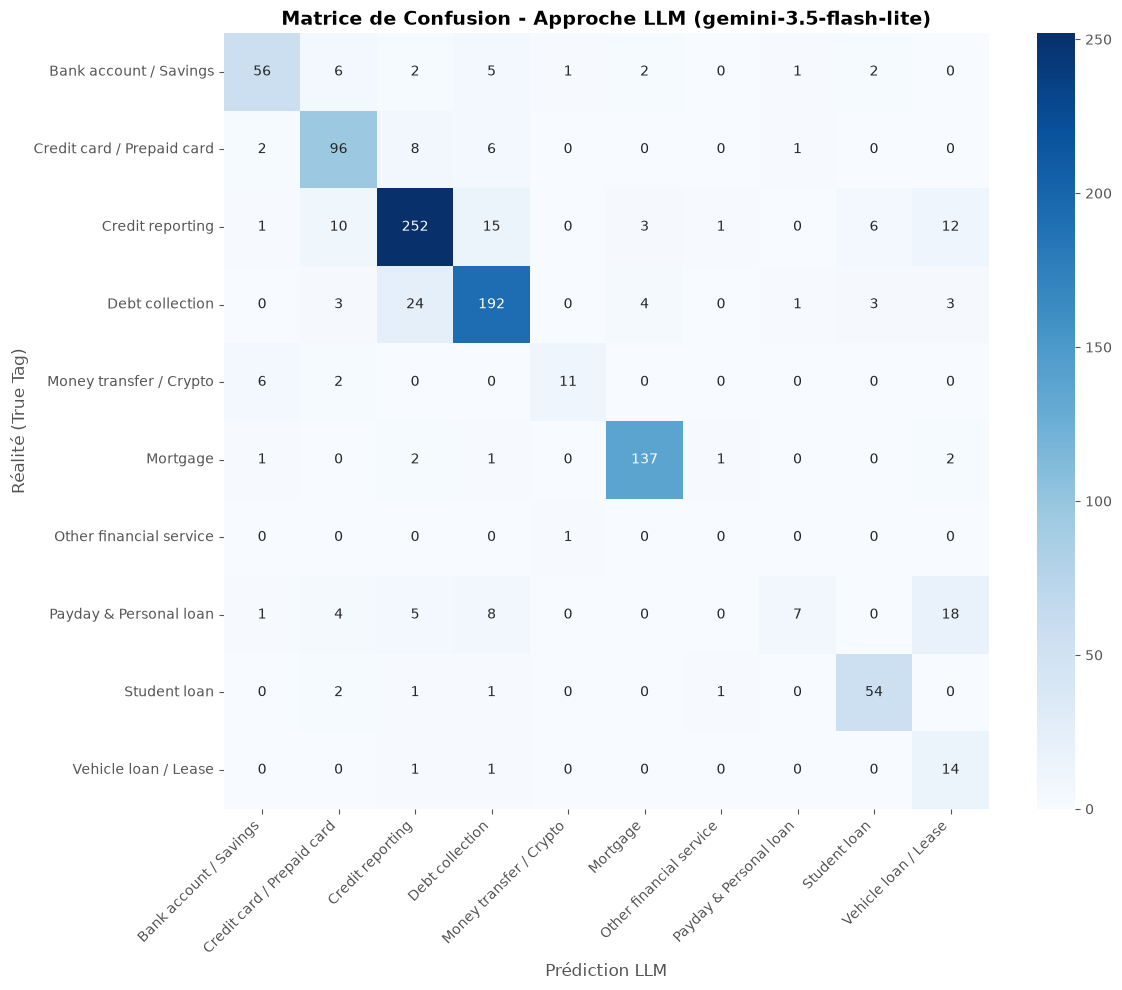

In [10]:
labels = sorted(list(set(y_true) | set(y_pred)))
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Matrice de Confusion - Approche LLM ({MODEL_NAME})', fontsize=14, fontweight='bold')
plt.xlabel('Prédiction LLM')
plt.ylabel('Réalité (True Tag)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('dataset/llm_confusion_matrix.png', dpi=300)
plt.show()